# Data Project - Stock Market Analysis



Zaman serisi verileri, zaman sırasına göre indekslenmiş veri noktalarından oluşan bir seridir. Zaman serisi verileri her yerdedir, bu nedenle bunları manipüle etmek herhangi bir veri analisti veya veri bilimci için önemlidir.  Bu not defterinde, borsa verilerini, özellikle bazı teknoloji hisse senetlerini (Apple, Amazon, Google ve Microsoft) keşfedecek ve inceleyeceğiz. Hisse senedi bilgisi almak için yfinance kullanımını öğrenecek ve Seaborn ile Matplotlib kullanarak bunun farklı yönlerini görselleştireceğiz. Önceki performans geçmişine dayanarak bir hisse senedinin riskini analiz etmenin birkaç yoluna bakacağız. Ayrıca Uzun Kısa Süreli Bellek (LSTM) yöntemini kullanarak gelecekteki hisse senedi fiyatlarını tahmin edeceğiz!  Süreç boyunca şu soruları yanıtlıyor olacağız:  1.) Zaman içinde hisse senedi fiyatındaki değişim neydi?
2.) Hisse senedinin ortalama günlük getirisi neydi?
3.) Çeşitli hisse senetlerinin hareketli ortalaması neydi?
4.) Farklı hisse senetleri arasındaki korelasyon nasıldı?
5.) Belirli bir hisse senedine yatırım yaparak ne kadar riske girmiş oluyoruz?
6.) Gelecekteki hisse senedi davranışını tahmin etmeye nasıl çalışabiliriz? (LSTM kullanarak APPLE Inc.'in kapanış hisse senedi fiyatını tahmin etme)  Verileri Almak
İlk adım verileri almak ve belleğe yüklemektir. Hisse senedi verilerimizi Yahoo Finance web sitesinden alacağız. Yahoo Finance, finansal piyasa verileri ve cazip yatırımlar bulma araçları açısından zengin bir kaynaktır. Yahoo Finance'ten veri almak için, Yahoo'dan piyasa verilerini indirmek için iş parçacıklı (threaded) ve Pythonik bir yol sunan yfinance kütüphanesini kullanacağız.



### 1. Zaman İçinde Hisse Senedi Fiyatındaki Değişim Nedir?
Bu bölümde, pandas ile hisse senedi bilgisi istemeyi ve bir hisse senedinin temel niteliklerini nasıl analiz edeceğimizi ele alacağız.

In [ ]:
# 📈 PyTorch ile Hisse Senedi Fiyat Tahmini (LSTM & GRU)

Bu projede, Yahoo Finance (`yfinance`) verileri kullanılarak geçmiş borsa verileri üzerinden derin öğrenme modelleri (**LSTM** ve **GRU**) ile gelecek fiyat tahminleri yapılmıştır.


In [ ]:
!pip install -q yfinance

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr



# For time stamps
from datetime import datetime


# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Set up End and Start times for data grab
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)


company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name

df = pd.concat(company_list, axis=0)
df.tail(10)

/tmp/ipykernel_2172/2101200153.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2172/2101200153.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2172/2101200153.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2172/2101200153.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,GOOG,GOOG,GOOG,GOOG,...,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-31,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,271.579987,273.230011,262.010010,265.000000,129054800.0
2026-08-03,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,284.019989,287.200012,278.000000,278.290009,90830200.0
2026-08-04,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,277.420013,281.070007,275.820007,276.059998,69748100.0
2026-08-05,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,272.649994,282.790009,270.730011,281.589996,45119800.0
2026-08-06,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,272.260010,275.480011,271.059998,272.769989,30672900.0
2026-08-07,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,274.480011,278.309998,272.750000,272.869995,33861400.0
2026-08-10,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,278.089996,280.140015,273.600006,274.010010,35731900.0
2026-08-11,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,272.269989,278.839996,271.359985,278.690002,31895700.0


### 1, 2 & 3. Veri İçe Aktarma, Yapı ve Eksik Değer Analizi
* **Veri Kaynağı:** Yahoo Finance (`yfinance`) üzerinden teknoloji devlerinin (`AAPL`, `GOOG`, `MSFT`, `AMZN`) son 1 yıllık verileri çekilmiştir.
* **Veri Yapısı:** Sütun tipleri ve eksik/null değer kontrolleri tamamlanmıştır.

In [ ]:
# Summary Stats
AAPL.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,272.323262,275.018845,269.417548,272.060913,4.985839e+07
std,25.724868,26.016035,25.180339,25.389471,2.260936e+07
min,224.072266,225.686314,222.956393,225.337608,1.791060e+07
25%,255.394234,257.399153,253.114986,255.129703,3.907225e+07
50%,269.046143,272.314026,266.244870,268.807025,4.522430e+07
75%,289.705139,292.618185,286.201637,289.124029,5.274305e+07
max,339.786926,344.273097,337.059318,339.736982,2.617755e+08


Veride hafta sonları yer almadığı için bir yılda yalnızca 255 kaydımız var.

In [ ]:
# General info
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-08-14 to 2026-08-13
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, AAPL)     251 non-null    float64
 1   (High, AAPL)      251 non-null    float64
 2   (Low, AAPL)       251 non-null    float64
 3   (Open, AAPL)      251 non-null    float64
 4   (Volume, AAPL)    251 non-null    int64  
 5   (company_name, )  251 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 13.7+ KB


## Kapanış Fiyatı

Kapanış fiyatı, normal işlem günü sırasında hisse senedinin işlem gördüğü son fiyattır. Bir hisse senedinin kapanış fiyatı, yatırımcıların performansını zaman içinde takip etmek için kullandığı standart ölçüttür.

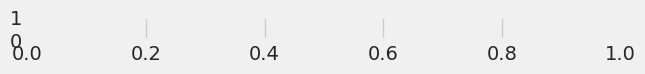

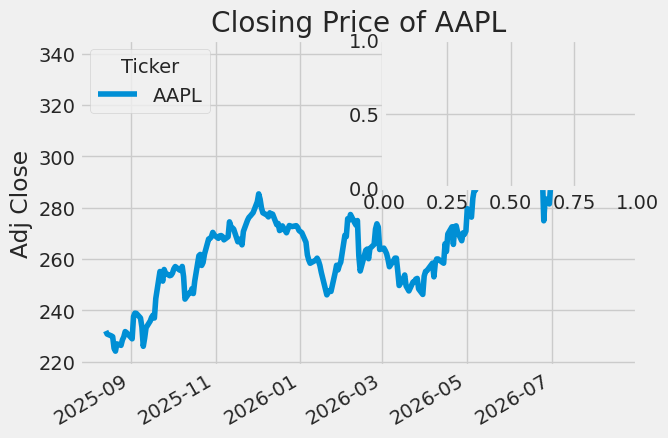

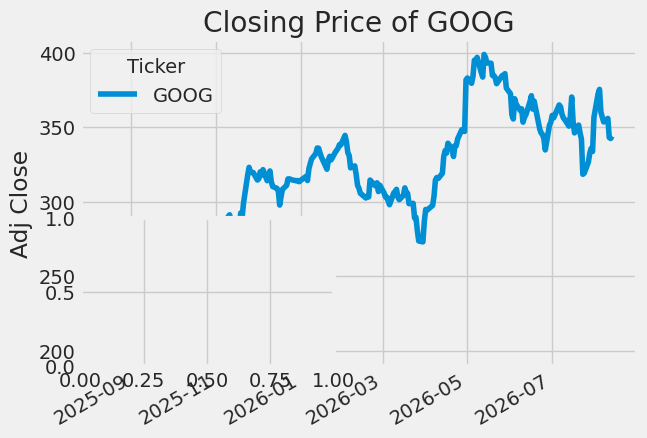

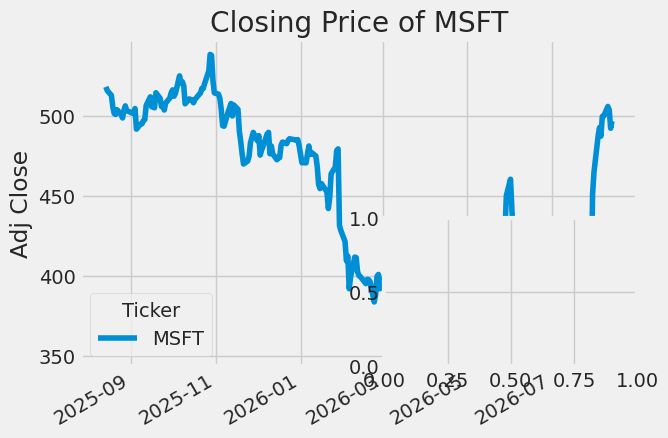

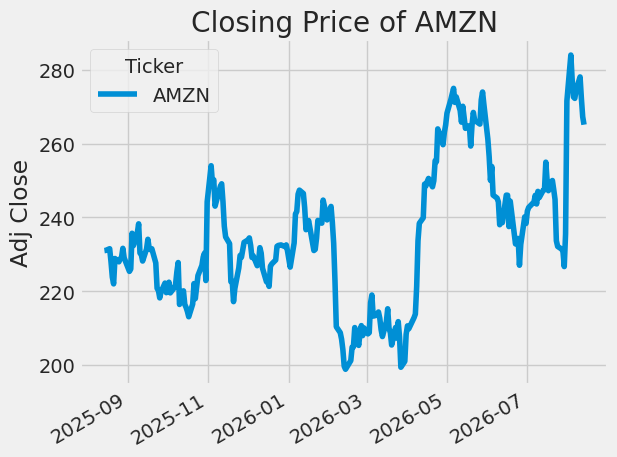

In [ ]:
# Let's see a historical view of the closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Close'].plot()
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

## İşlem Hacmi (Volume of Sales)
İşlem hacmi, belirli bir süre boyunca (genellikle bir gün içinde) el değiştiren bir varlık veya menkul kıymetin miktarını ifade eder[cite: 1]. Örneğin, hisse senedi işlem hacmi, günlük açılış ve kapanış arasında işlem gören hisse senedi sayısını belirtir[cite: 1]. İşlem hacmi ve zaman içindeki hacim değişimleri, teknik yatırımcılar için önemli girdilerdir[cite: 1].

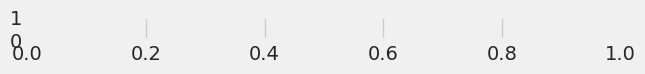

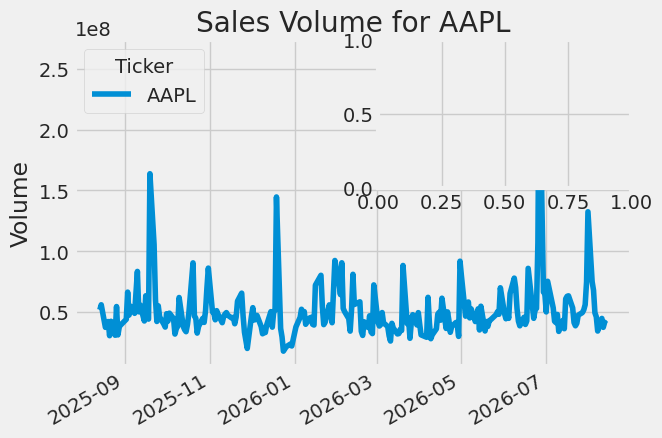

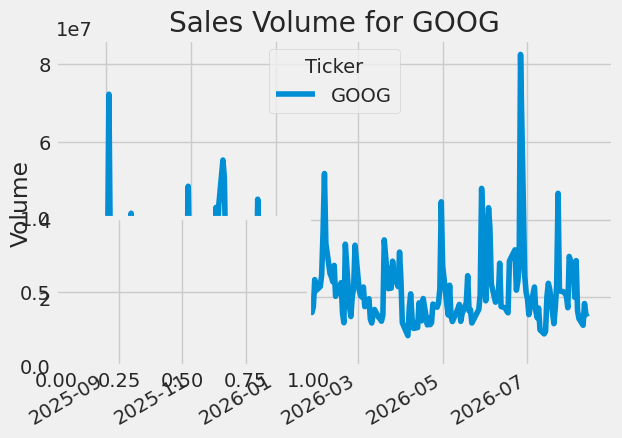

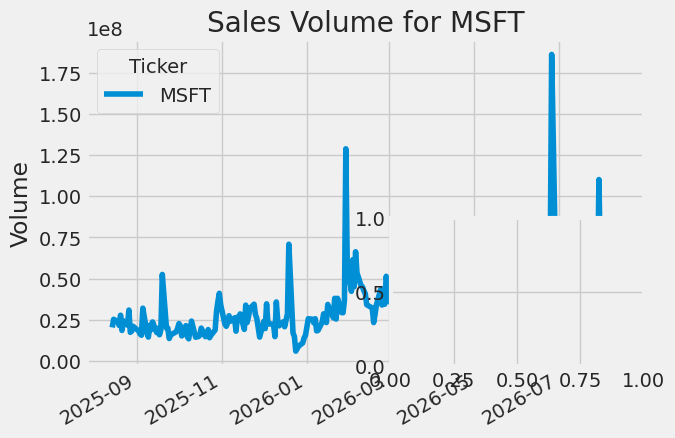

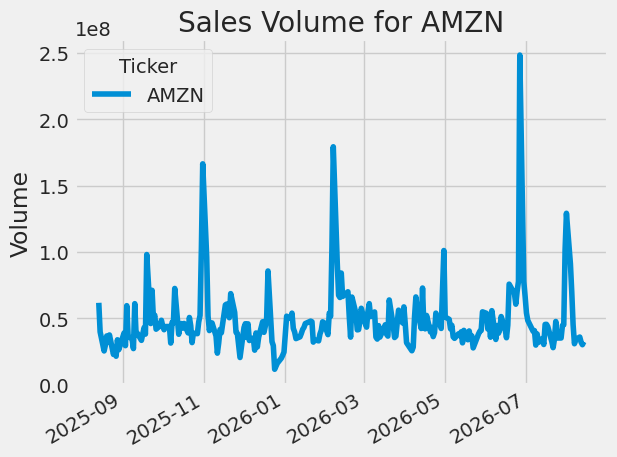

In [ ]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

Kapanış fiyatı ve her gün işlem gören hacim görselleştirmelerini gördüğümüze göre, şimdi hisse senedi için hareketli ortalamayı hesaplayalım.

### 2. Çeşitli Hisselerin Hareketli Ortalaması (Moving Average) neydi?
Hareketli ortalama (MA), sürekli güncellenen bir ortalama fiyat oluşturarak fiyat verilerini yumuşatan basit bir teknik analiz aracıdır. Ortalama; 10 gün, 20 dakika, 30 hafta veya yatırımcının seçtiği herhangi bir zaman dilimi gibi belirli bir süre üzerinden alınır.

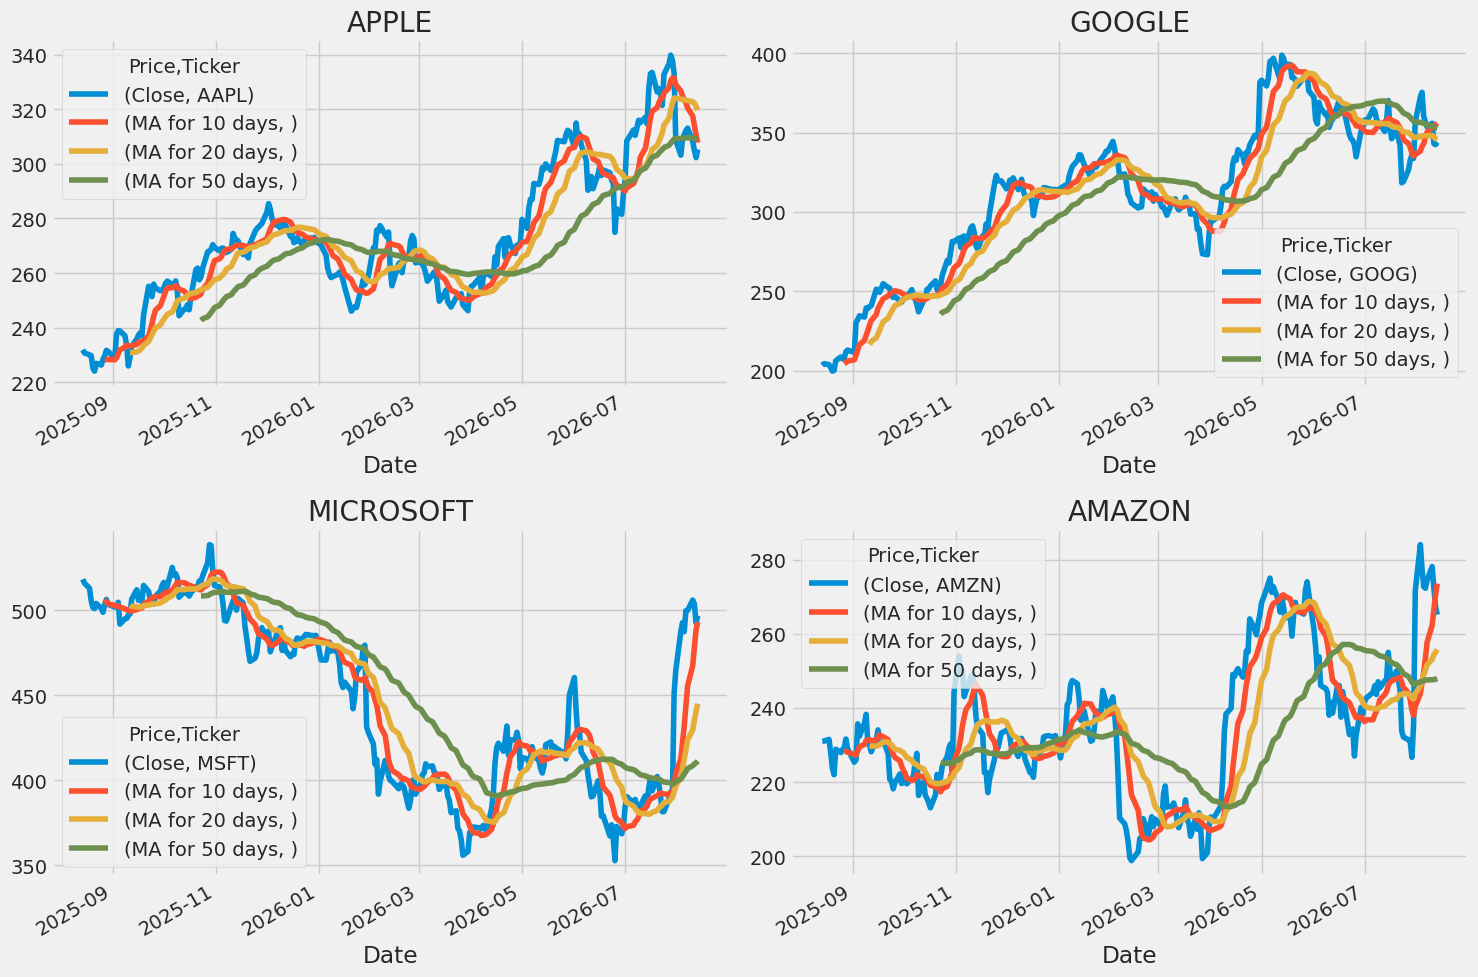

In [ ]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Close'].rolling(ma).mean()


fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

Grafikte, hareketli ortalamayı ölçmek için en iyi değerlerin 10 ve 20 gün olduğunu görüyoruz çünkü gürültü olmadan verilerdeki trendleri yakalayabiliyoruz.

### 3. Hisse Senedinin Ortalama Günlük Getirisi Ne Kadardı?

Temel analizi tamamladığımıza göre, biraz daha derine inelim. Şimdi hisse senedinin riskini analiz edeceğiz. Bunu yapmak için, yalnızca mutlak değerine değil, hisse senedinin günlük değişimlerine daha yakından bakmamız gerekecek. Pandas kullanarak Apple hissesinin günlük getirilerini alalım.

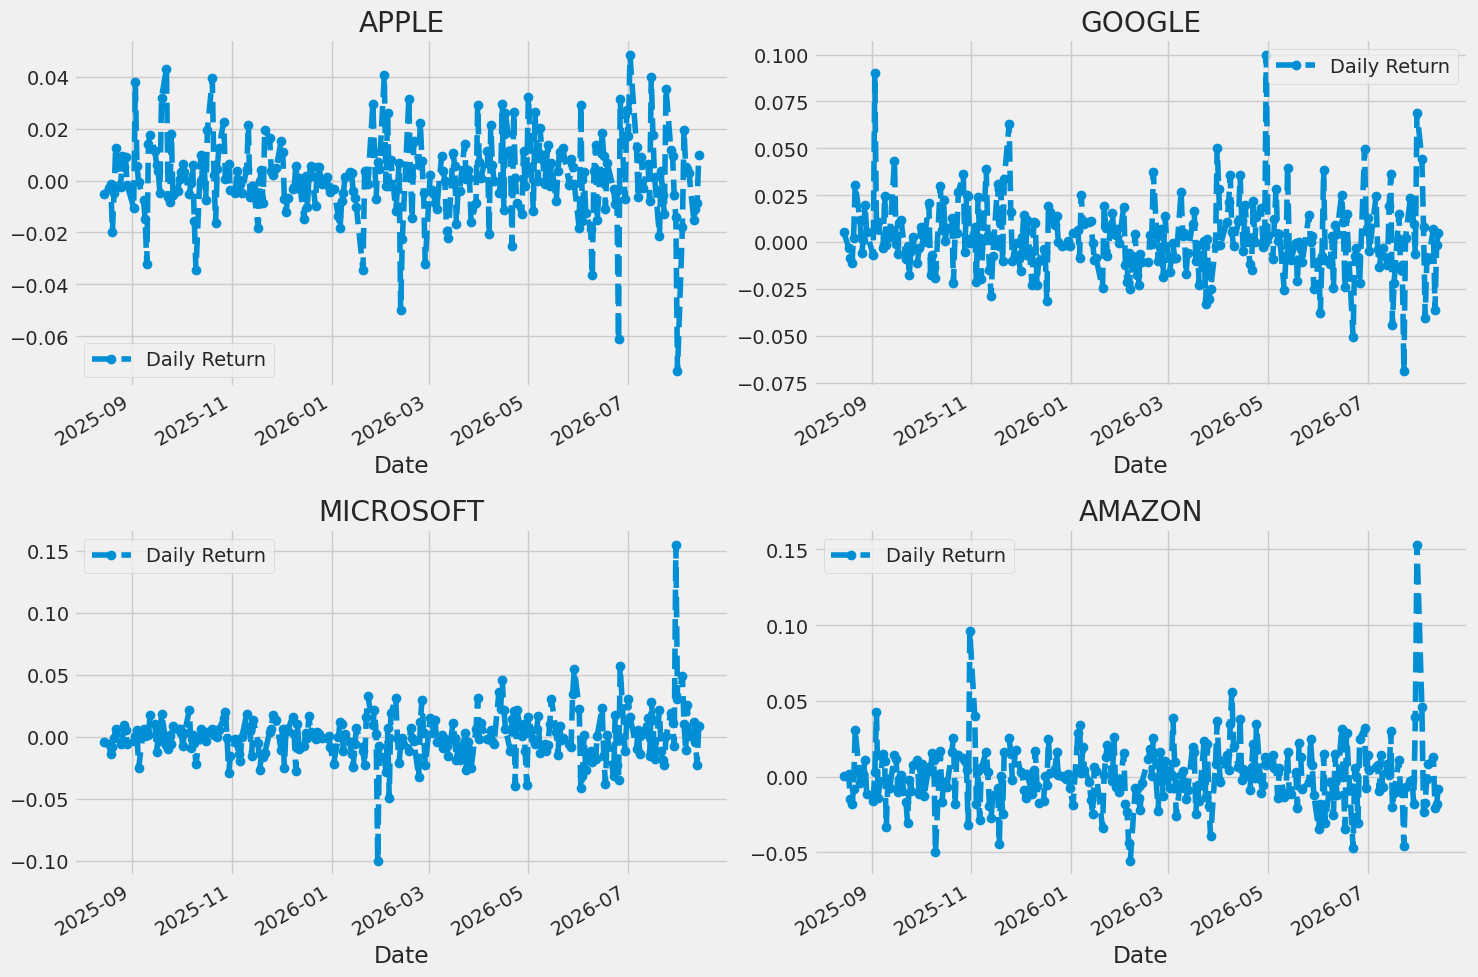

In [ ]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

Şimdi bir histogram kullanarak ortalama günlük getiriye genel bir bakış atalım. Aynı figür hem histogram hem de KDE grafiği oluşturmak için seaborn kullanacağız.

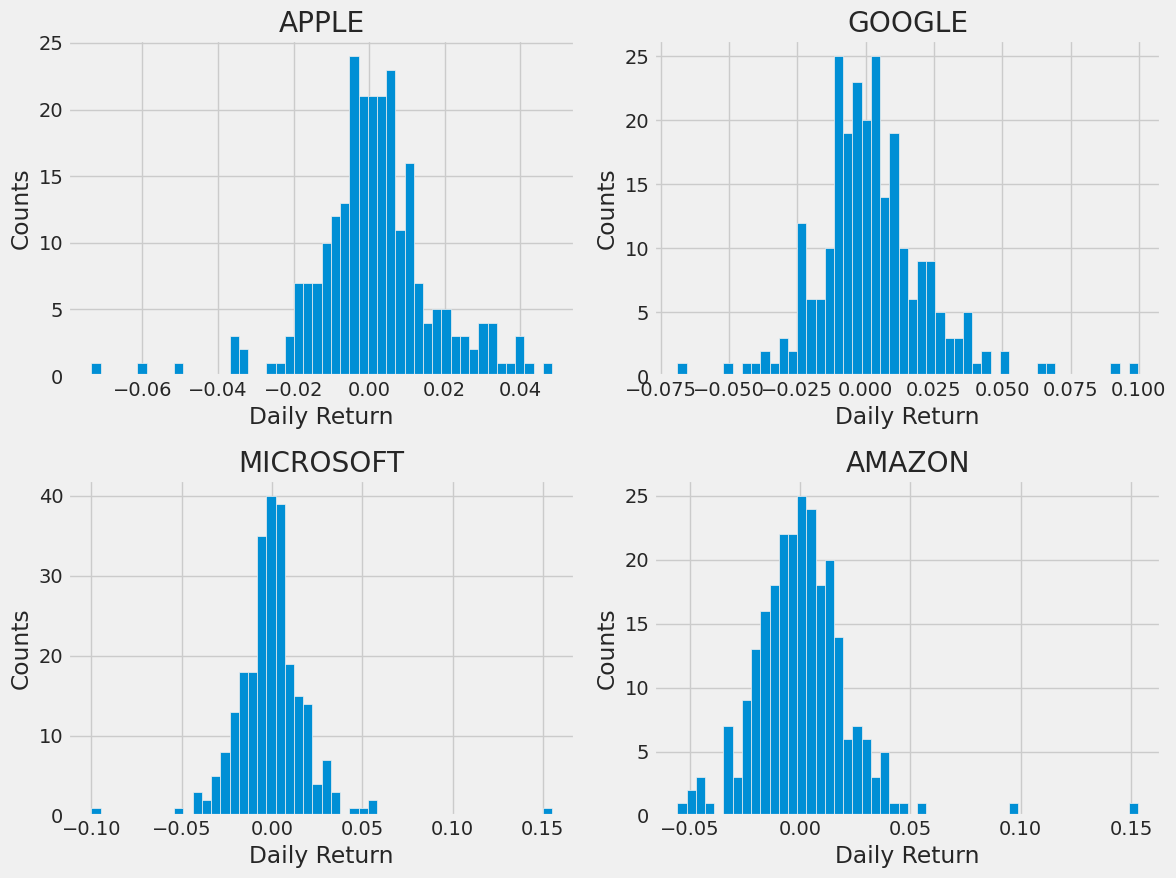

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')

plt.tight_layout()

# 4. Farklı hisse senetlerinin kapanış fiyatları arasındaki korelasyon neydi?

Korelasyon, iki değişkenin birbirine göre hareket etme derecesini ölçen ve değeri -1,0 ile +1,0 aralığında olması gereken bir istatistiksel değerdir. Korelasyon bir ilişkiyi ölçer; ancak x'in y'ye (veya tam tersine) neden olup olmadığını ya da bu ilişkinin üçüncü bir faktörden kaynaklanıp kaynaklanmadığını göstermez[1].

Peki, ya listemizdeki tüm hisse senetlerinin getirilerini analiz etmek istersek? Gelin, her bir hisse senedi DataFrame'indeki ['Close'] (Kapanış) sütunlarını kullanarak bir DataFrame oluşturalım.

In [ ]:
# Grab all the closing prices for the tech stock list into one DataFrame

closing_df = yf.download(tech_list, start=start, end=end)['Close']

# Make a new tech returns DataFrame
tech_rets = closing_df.pct_change()
tech_rets.head()

/tmp/ipykernel_2172/3407210578.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_df = yf.download(tech_list, start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2025-08-14,NaN,NaN,NaN,NaN
2025-08-15,-0.005112,0.000216,0.005348,-0.004421
2025-08-18,-0.003023,0.001991,-0.003026,-0.005902
2025-08-19,-0.001429,-0.015033,-0.008811,-0.014175
2025-08-20,-0.019735,-0.018420,-0.011359,-0.007945


Şimdi, ne ölçüde ilişkili olduklarını görmek için iki hisse senedinin günlük getiri yüzdelerini karşılaştırabiliriz. Öncelikle, bir hisse senedini kendisiyle karşılaştırarak inceleyelim.

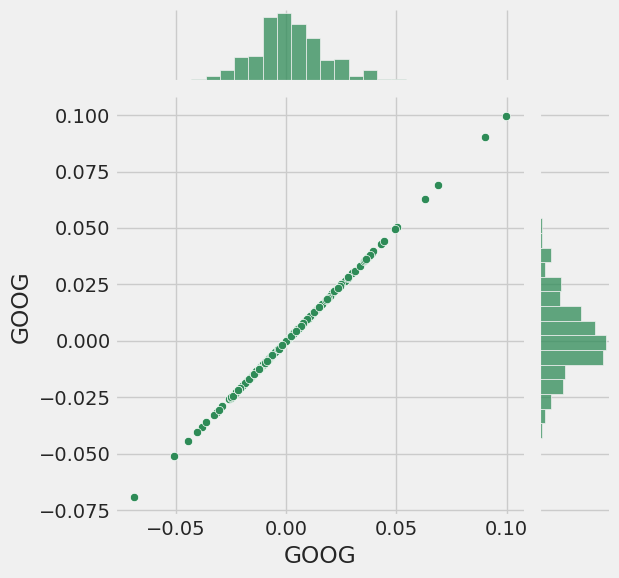

In [ ]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

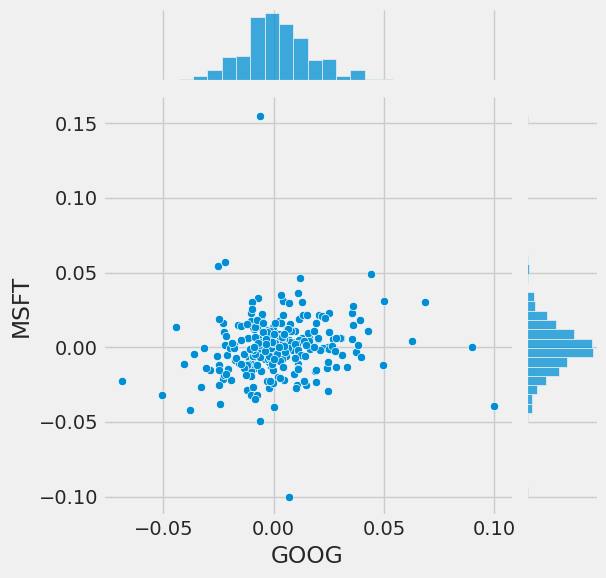

In [ ]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

Artık görüyoruz ki, eğer iki hisse senedi birbiriyle mükemmel (ve pozitif) bir korelasyona sahipse, bu hisselerin günlük getiri değerleri arasında doğrusal bir ilişki ortaya çıkacaktır.

Seaborn ve pandas, teknoloji hissesi sembolleri listemizdeki tüm olası hisse senedi kombinasyonları için bu karşılaştırma analizini tekrarlamayı son derece kolaylaştırıyor. Bu grafiği otomatik olarak oluşturmak için `sns.pairplot()` fonksiyonunu kullanabiliriz.

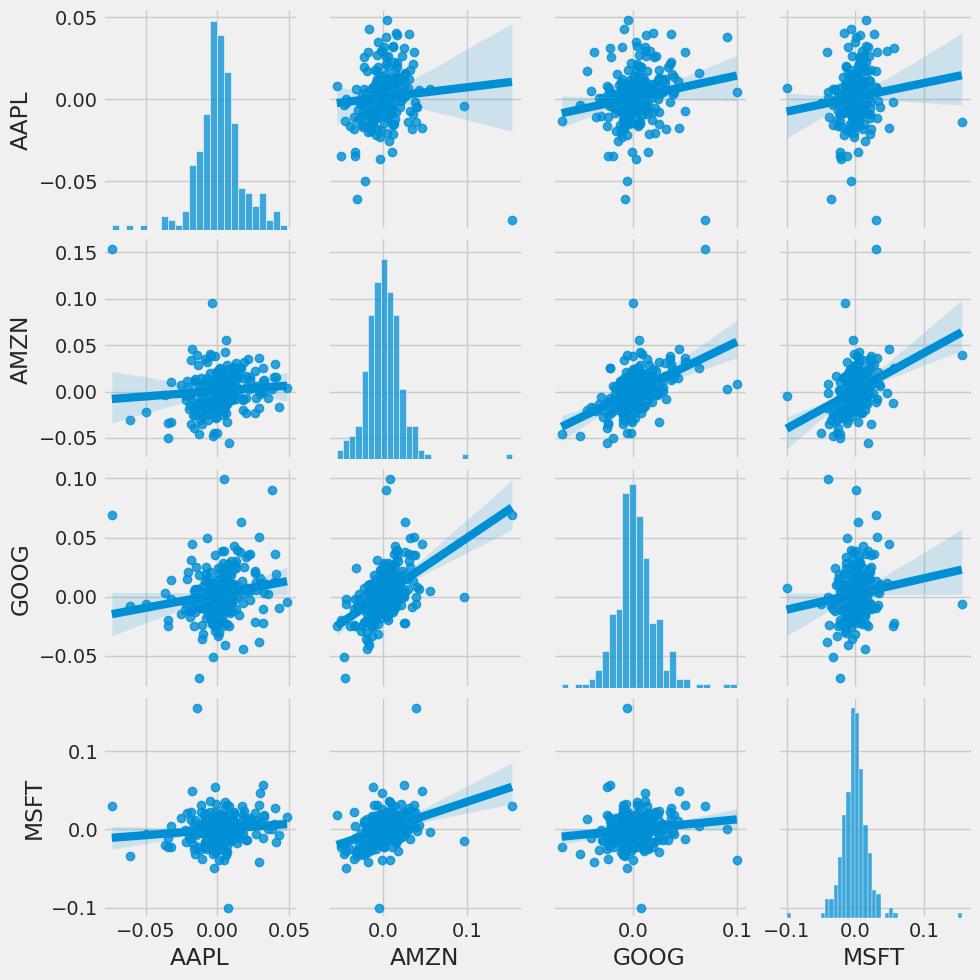

In [ ]:
# We can simply call pairplot on our DataFrame for an automatic visual analysis
# of all the comparisons

sns.pairplot(tech_rets, kind='reg')

Yukarıda, tüm hisse senetlerinin günlük getirileri arasındaki ilişkilerin tamamını görebiliyoruz. Hızlı bir bakış, Google ve Amazon'un günlük getirileri arasında ilginç bir korelasyon olduğunu gösteriyor. Bu özel karşılaştırmayı incelemek ilginç olabilir.

Sadece `sns.pairplot()` fonksiyonunu çağırmanın sağladığı basitlik harika olsa da, grafik üzerinde tam kontrol sağlamak (örneğin köşegen, üst üçgen ve alt üçgen kısımlarında hangi tür grafiklerin yer alacağını belirlemek) amacıyla `sns.PairGrid()` de kullanılabilir. Aşağıda, bu sonucu elde etmek için seaborn'un tüm olanaklarından yararlanılan bir örnek yer almaktadır.

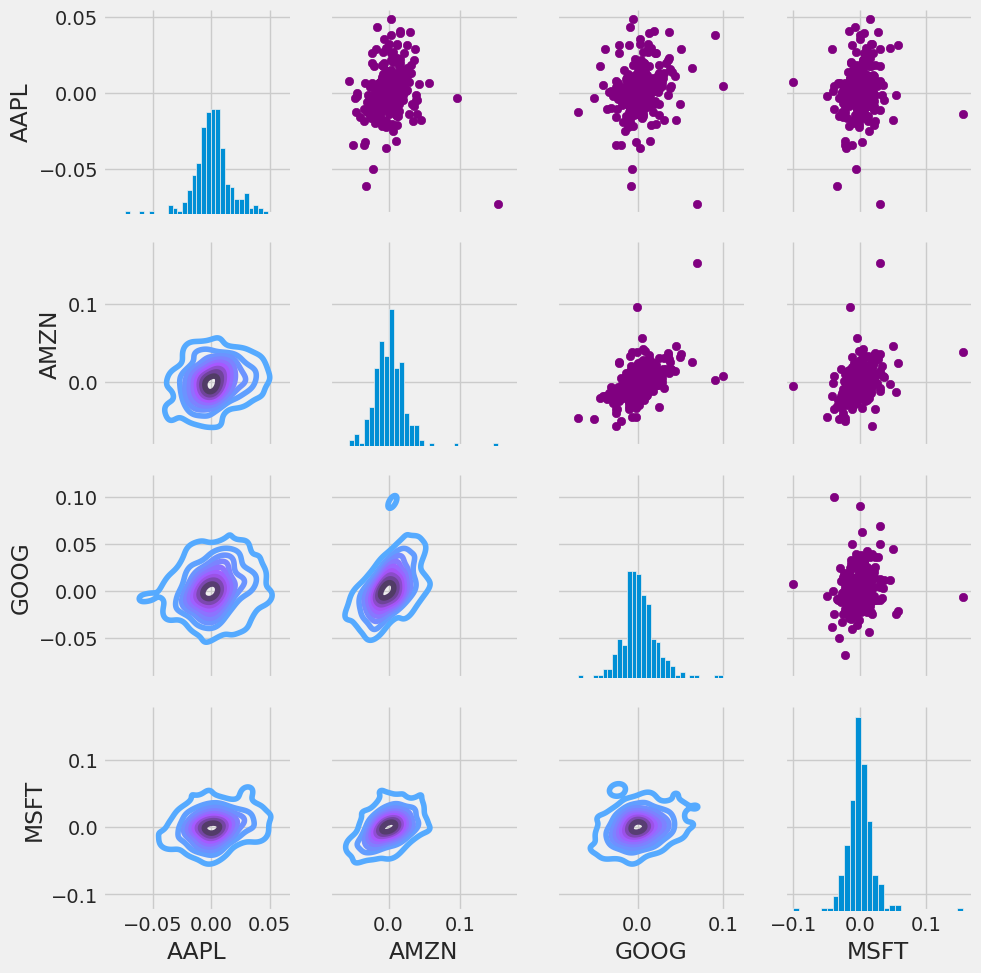

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde)
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

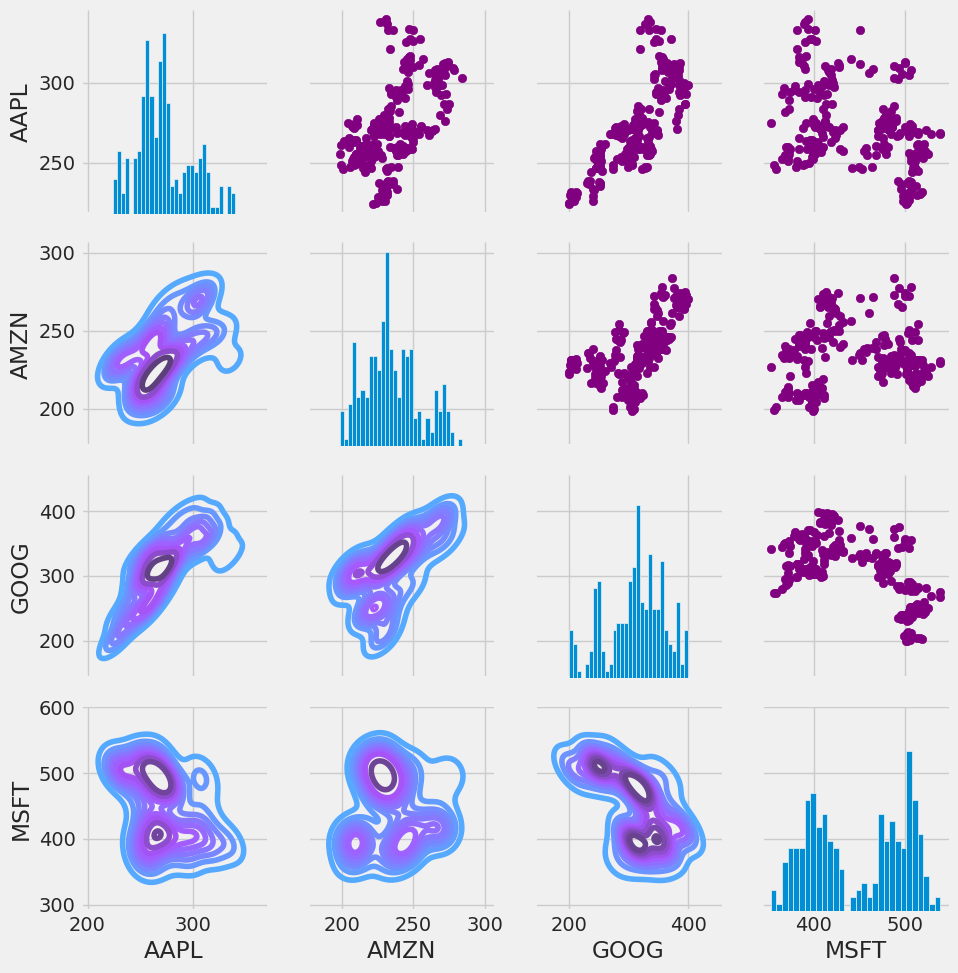

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Son olarak, hisse senetlerinin günlük getiri değerleri arasındaki korelasyona dair somut sayısal değerler elde etmek amacıyla bir korelasyon grafiği de oluşturabiliriz. Kapanış fiyatlarını karşılaştırdığımızda, Microsoft ile Apple arasında ilginç bir ilişki olduğunu görüyoruz.

Text(0.5, 1.0, 'Correlation of stock closing price')

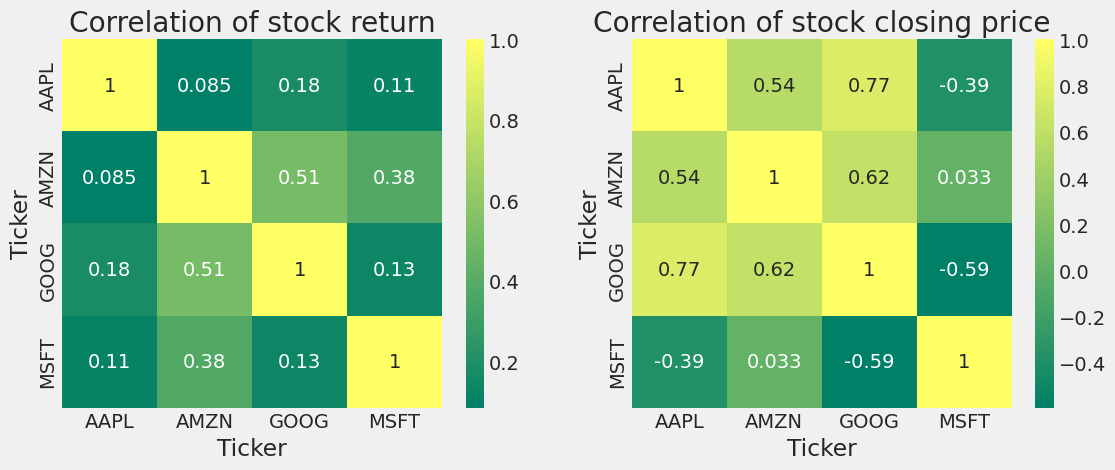

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

`PairPlot` analizimizde şüphelendiğimiz gibi, burada Microsoft ve Amazon'un günlük hisse senedi getirileri arasında en güçlü korelasyonun bulunduğunu hem sayısal hem de görsel olarak görüyoruz. Ayrıca tüm teknoloji şirketlerinin pozitif korelasyona sahip olduğunu görmek de ilgi çekici.

# 5. Belirli bir hisse senedine yatırım yaparak ne kadarlık bir değeri riske atıyoruz?

Riski ölçebileceğimiz pek çok yol vardır; günlük yüzdesel getirilere ilişkin topladığımız bilgileri kullanarak başvurabileceğimiz en temel yöntemlerden biri, beklenen getiriyi günlük getirilerin standart sapmasıyla karşılaştırmaktır.

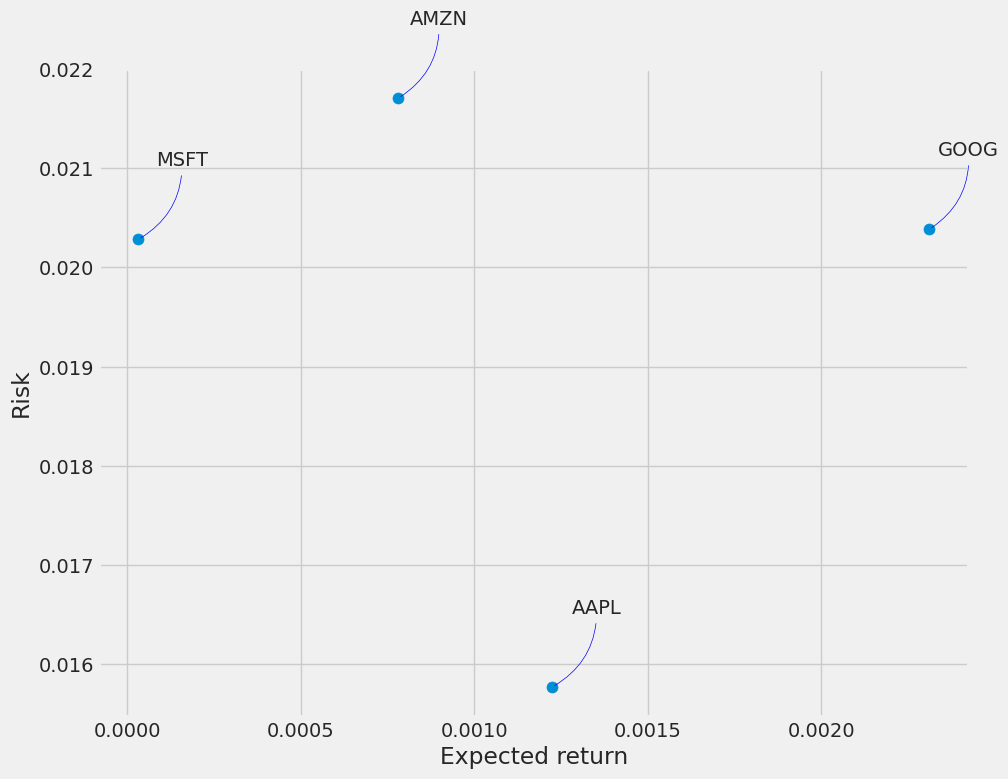

In [31]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

# 6. Apple Inc. hisse senedinin kapanış fiyatını tahmin etme:

In [ ]:
# Get the stock quote
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())['Close']
# Show the data
df

/tmp/ipykernel_2172/2806980434.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2012-01-01', end=datetime.now())['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2012-01-03,12.299739
2012-01-04,12.365838
2012-01-05,12.503120
2012-01-06,12.633829
2012-01-09,12.613789
...,...
2026-08-07,313.059998
2026-08-10,308.260010
2026-08-11,304.910004


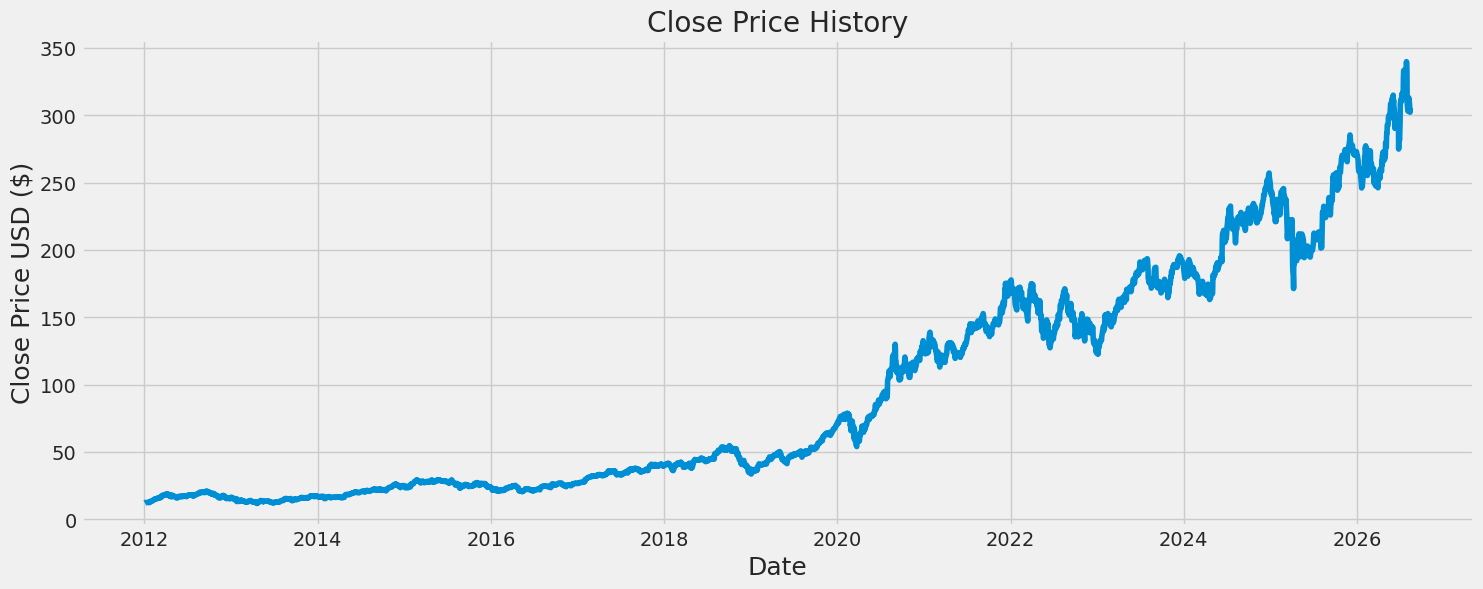

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
# df already contains the 'Close' prices as a single-column DataFrame.
# Convert the dataframe to a numpy array directly.
dataset = df.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3491

### 6 & 7. Veri Setinin Bölünmesi ve Model Hazırlığı (Sliding Window)
* **Veri Bölme:** Verinin büyük kısmı eğitim, kalan kısmı ise test için ayrılmıştır.
* **Kayan Pencere (Sliding Window):** Zaman serisi mimarisine uygun olarak, son 60 günün verisi kullanılarak sonraki günün tahmin edilmesini sağlayan yapı kurulmuş ve PyTorch Tensörlerine dönüştürülmüştür.

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

# Ensure dataset has the correct shape for MinMaxScaler
# It was likely incorrectly created as an empty array in the previous cell.
# Re-create it from the 'df' variable which holds the stock data.
# 'df' is a DataFrame with one column, so df.values will be a 2D array (3667, 1).
dataset = df.values

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00136223],
       [0.00156379],
       [0.00198242],
       ...,
       [0.89364649],
       [0.88553509],
       [0.8947138 ]])

### 4. Veri Düzeltme ve Feature Engineering (Ölçeklendirme)
* Modelin hata oranını düşürmek ve öğrenme verimliliğini artırmak için `Close` (kapanış) fiyatları seçilmiştir.
* Veriler `MinMaxScaler` kullanılarak **[0, 1]** aralığına normalize edilmiştir.


In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.00136223, 0.00156379, 0.00198242, 0.002381  , 0.00231989,
       0.00245761, 0.00239467, 0.00228888, 0.00214477, 0.00259077,
       0.00299299, 0.00286895, 0.00218946, 0.00283794, 0.00219951,
       0.00459366, 0.00440851, 0.00465022, 0.00517282, 0.0054893 ,
       0.00546287, 0.00536527, 0.00578116, 0.00617244, 0.00661571,
       0.00733167, 0.00883567, 0.00885847, 0.00969574, 0.0103214 ,
       0.0092461 , 0.00966017, 0.00965198, 0.01081303, 0.01064795,
       0.01095346, 0.01150253, 0.0118081 , 0.01268823, 0.01332941,
       0.01351453, 0.0135793 , 0.012483  , 0.01221852, 0.01225775,
       0.01328836, 0.01357839, 0.01420133, 0.01566975, 0.01762887,
       0.01726222, 0.0172631 , 0.01867953, 0.01912282, 0.01880725,
       0.01851903, 0.01821895, 0.01921586, 0.01989989, 0.0201863 ])]
[np.float64(0.019478524314752617)]

[array([0.00136223, 0.00156379, 0.00198242, 0.002381  , 0.00231989,
       0.00245761, 0.00239467, 0.00228888, 0.00214477, 0.00259077,
       0.00299299, 0.0

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Verileri PyTorch Tensor'lerine Çevirme
# Üst hücrelerde oluşturulan numpy dizilerini (x_train ve y_train) PyTorch'un
# anlayacağı tensor formatına dönüştürüyoruz.
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# Veri yükleyici (DataLoader) oluşturma
# Keras'ta batch_size=1 kullanılmış ancak PyTorch'ta tek tek eğitmek uzun sürer.
# İşlemi hızlandırmak için verileri 16'şarlı paketler (batch) halinde eğiteceğiz.
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# 2. PyTorch ile LSTM Modelini İnşa Etme
class StockPredictionLSTM(nn.Module):
    def __init__(self):
        super(StockPredictionLSTM, self).__init__()

        # İlk LSTM katmanı (Keras'taki LSTM(128, return_sequences=True) karşılığı)
        # input_size=1 çünkü sadece 'Close' fiyatı giriyor.
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=128, batch_first=True)

        # İkinci LSTM katmanı (Keras'taki LSTM(64, return_sequences=False) karşılığı)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)

        # Tam Bağlantılı Katmanlar (Keras'taki Dense(25) ve Dense(1) karşılıkları)
        self.fc1 = nn.Linear(64, 25)
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        # 1. LSTM Katmanı
        out, _ = self.lstm1(x)
        # 2. LSTM Katmanı
        out, _ = self.lstm2(out)

        # Keras'taki return_sequences=False mantığı:
        # Sadece dizinin en son zaman adımını (last time step) alıyoruz.
        last_time_step = out[:, -1, :]

        # Dense (Linear) katmanlardan geçiş
        x = self.fc1(last_time_step)
        x = self.fc2(x)
        return x

# Modeli çağırma, Hata (Loss) fonksiyonu ve Optimizasyon
model = StockPredictionLSTM()
criterion = nn.MSELoss() # Keras'taki loss='mean_squared_error'
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Keras'taki optimizer='adam'

# 3. Modeli Eğitme (Keras'taki model.fit kısmının karşılığı)
epochs = 1 # Resimdeki örnekte epochs=1 verilmiş.
print("PyTorch ile Model Eğitimi Başlıyor...")

for epoch in range(epochs):
    epoch_loss = 0.0

    # DataLoader üzerinden batch'leri çekerek eğitiyoruz
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()              # Önceki hesaplamaları (gradyanları) sıfırla
        outputs = model(batch_X)           # Tahmin yap
        loss = criterion(outputs, batch_y) # Tahmin ile gerçek değer arasındaki hatayı hesapla
        loss.backward()                    # Geri yayılım (backpropagation) ile hatayı dağıt
        optimizer.step()                   # Ağırlıkları güncelle (öğren)

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")

print("Eğitim başarıyla tamamlandı! 🎉")

PyTorch ile Model Eğitimi Başlıyor...
Epoch [1/1], Loss: 0.0052
Eğitim başarıyla tamamlandı! 🎉


In [38]:
import torch
import torch.nn as nn

# 1. Test Veri Setini Hazırlama
# Eğitim verisi uzunluğundan 60 gün öncesinden başlayarak test verisini alıyoruz
test_data = scaled_data[training_data_len - 60:, :]

x_test = []
# y_test'i doğrudan numpy dizisi olarak alıyoruz
# Note: This y_test is not used in RMSE calculation, y_test_array is.
# It's kept for consistency with original notebook's intent for local scope.
y_test = df.iloc[training_data_len:].values # Ensure y_test is a numpy array

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Veriyi numpy array formatına çeviriyoruz
x_test = np.array(x_test)

# LSTM'in beklediği 3 boyutlu formata getiriyoruz: (Batch, Sequence, Features)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# 2. PyTorch Tensörüne Dönüştürme
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# 3. Model ile Tahmin Yapma (Evaluation Mode)
model.eval() # Modeli değerlendirme moduna alıyoruz
with torch.no_grad():
    predictions_tensor = model(X_test_tensor)

# 4. Tahminleri NumPy dizisine çevirip ölçeği geri alıyoruz (Normal fiyat boyutuna döndürme)
predictions = predictions_tensor.numpy()
predictions = scaler.inverse_transform(predictions)

# 5. Hata (RMSE) Hesaplama Hazırlığı
# y_test'in boyutunu ve tipini predictions ile birebir aynı yapıyoruz
y_test_array = df.iloc[training_data_len:].values # Directly get values from original df

# Reshape if it's a 1D array (e.g., if df was a Series, .values would be 1D)
if len(y_test_array.shape) == 1:
    y_test_array = np.reshape(y_test_array, (-1, 1))

# Root Mean Squared Error (RMSE) hesaplama
rmse = np.sqrt(np.mean((predictions - y_test_array) ** 2))
print(f"Test RMSE Değeri: {rmse}")

Test RMSE Değeri: 11.788059864053398


/tmp/ipykernel_2172/656684194.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid.loc[:, 'Predictions'] = predictions


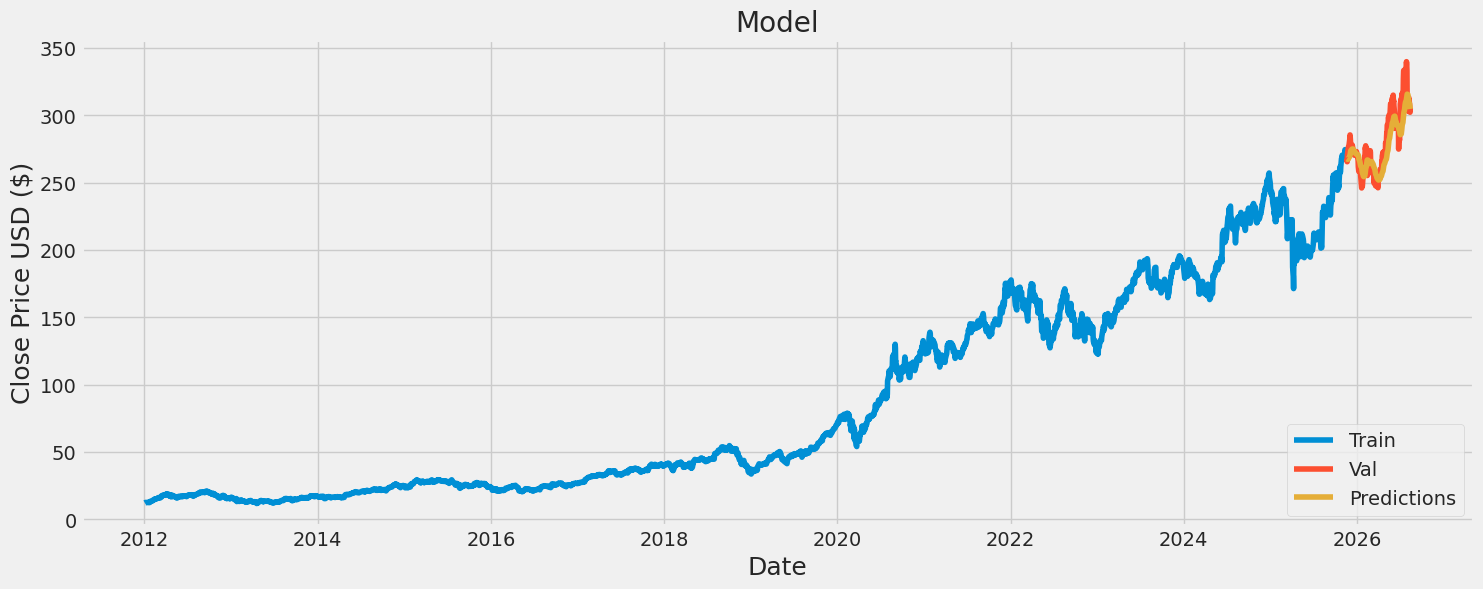

In [ ]:
# Plot the data
train = df[:training_data_len]
valid = df[training_data_len:]
valid.loc[:, 'Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['AAPL'])
plt.plot(valid[['AAPL', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

### 5. Geçmiş Veri Görselleştirilmesi
Seçilen hisse senedinin yıllara göre kapanış fiyatı değişim grafiği çizdirilmiştir.


In [39]:
# Show the valid and predicted prices
valid

Ticker,AAPL,Predictions
Date,,
2025-11-19,267.830963,267.758301
2025-11-20,265.527252,267.652893
2025-11-21,270.752991,267.403381
2025-11-24,275.170990,267.330780
2025-11-25,276.218170,267.580841
...,...,...
2026-08-07,313.059998,309.630035
2026-08-10,308.260010,308.459656
2026-08-11,304.910004,307.277924


In [40]:
import time
import torch.nn as nn

# 1. GRU Model Mimarisini Tanımlama (LSTM'in GRU karşılığı)
class StockPredictionGRU(nn.Module):
    def __init__(self):
        super(StockPredictionGRU, self).__init__()
        # Keras'taki GRU katmanlarına benzer şekilde 2 katmanlı bir GRU kuruyoruz
        self.gru1 = nn.GRU(input_size=1, hidden_size=128, num_layers=2, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(128, 25)
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        out, _ = self.gru1(x)
        out = self.fc1(out[:, -1, :]) # Sadece son zaman adımının çıktısını alıyoruz
        out = self.fc2(out)
        return out

# Modeli ve optimizer'ı tanımlayalım
gru_model = StockPredictionGRU()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

# 2. GRU Modelini Eğitme ve Süre Ölçme
print("GRU modeli eğitiliyor...")
start_time = time.time()

epochs = 5 # Eğitim süresini hızlı görmek için başlangıç değeri (isteğe göre artırılabilir)
for epoch in range(epochs):
    gru_model.train()
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        outputs = gru_model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

gru_training_time = time.time() - start_time
print(f"GRU Eğitim Süresi: {gru_training_time:.2f} saniye")

# 3. GRU Test ve Tahmin Aşaması
gru_model.eval()
with torch.no_grad():
    gru_predictions_tensor = gru_model(X_test_tensor)

gru_predictions = gru_predictions_tensor.numpy()
gru_predictions = scaler.inverse_transform(gru_predictions)

# GRU için RMSE Hesaplama
gru_rmse = np.sqrt(np.mean((gru_predictions - y_test_array) ** 2))

# 4. LSTM vs GRU Karşılaştırma Özeti
print("\n--- MODEL KARŞILAŞTIRMA RAPORU ---")
print(f"LSTM Test RMSE: {rmse:.4f}")
print(f"GRU Test RMSE:  {gru_rmse:.4f}")
print(f"GRU Eğitim Süresi: {gru_training_time:.2f} sn (Genellikle GRU daha az parametre içerdiği için bir miktar daha hızlı eğitilir)")

GRU modeli eğitiliyor...
GRU Eğitim Süresi: 47.03 saniye

--- MODEL KARŞILAŞTIRMA RAPORU ---
LSTM Test RMSE: 11.7881
GRU Test RMSE:  13.6386
GRU Eğitim Süresi: 47.03 sn (Genellikle GRU daha az parametre içerdiği için bir miktar daha hızlı eğitilir)


### 8. Model Eğitimi, Tahmin ve Performans Karşılaştırması (LSTM vs GRU)
* **LSTM ve GRU** modelleri eğitilerek test verileri üzerinden tahminler yapılmıştır.
* Modellerin başarı durumları **RMSE (Hata Metriği)** ve **eğitim süreleri** üzerinden karşılaştırılmıştır.


# Özet
Bu not defterinde, hisse senedi verilerini keşfettik ve inceledik.

Özellikle şunları öğrendik:

- `yfinance` kullanarak Yahoo Finance web sitesinden borsa verilerinin nasıl yükleneceği.
- Pandas, Matplotlib ve Seaborn kullanarak zaman serisi verilerinin nasıl inceleneceği ve görselleştirileceği.
- Hisseler arasındaki korelasyonun nasıl ölçüleceği.
- Belirli bir hisse senedine yatırım yapmanın riskinin nasıl ölçüleceği.

Referanslar:
https://www.investopedia.com/terms/c/correlation.asp
[Jose Portilla Udemy Kursu: Veri Analizi ve Görselleştirme için Python Öğrenme](https://www.udemy.com/course/learning-python-for-data-analysis-and-visualization/)